# Figure 4 plotting

Independent plotting notebook. Panel A will be assembled manually; this notebook currently draws Panel B only.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path('/home/chenyh/workspace/fluProfiler')
RESULT_DIR = PROJECT_ROOT / 'paper/Code/Fig4_SCMS_FiLM_20260902/outputs_legacy'
OUTPUT_DIR = PROJECT_ROOT / 'paper/Code/Fig4_vaccine_selection_figure'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WHO_RANKING_CSV = RESULT_DIR / 'who_ranking_summary.csv'
RANDOM_BASELINE_CSV = RESULT_DIR / 'who_vs_random_baseline.csv'

CELL_COLOR = '#58A6D8'
CELL_EDGE = '#004CD6'
EGG_COLOR = '#FFA245'
EGG_EDGE = '#E55D00'
TEXT_COLOR = '#071A52'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.linewidth': 0.9,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
})

## Panel B

In [2]:
who_ranks = pd.read_csv(WHO_RANKING_CSV)
random_baseline = pd.read_csv(RANDOM_BASELINE_CSV)

consultation_labels = {
    39: '2023–2024 NH',
    40: '2024 SH',
    41: '2024–2025 NH',
    42: '2025 SH',
    43: '2025–2026 NH',
    44: '2026 SH',
}
passage_order = {'CELL': 0, 'EGG': 1}

panel_b_data = who_ranks.copy()
panel_b_data['season'] = panel_b_data['season'].astype(int)
panel_b_data['consultation'] = panel_b_data['season'].map(consultation_labels)
panel_b_data['passage_order'] = panel_b_data['passage'].map(passage_order)
panel_b_data = panel_b_data.sort_values(['season', 'passage_order'], kind='stable').reset_index(drop=True)
panel_b_data['y'] = np.arange(len(panel_b_data))
panel_b_data['y_label'] = panel_b_data.apply(
    lambda row: f"{row['consultation']} ({row['passage'].lower()})", axis=1
)

display(panel_b_data[[
    'consultation', 'passage', 'n_ranked_candidates',
    'WHO_recommended_strain', 'WHO_rank', 'WHO_percentile'
]])

,consultation,passage,n_ranked_candidates,WHO_recommended_strain,WHO_rank,WHO_percentile
0,2023–2024 NH,CELL,58,A/DARWIN/6/2021 CELL,3,0.964912
1,2023–2024 NH,EGG,58,A/DARWIN/9/2021 EGG,3,0.964912
2,2024 SH,CELL,57,A/MASSACHUSETTS/18/2022 CELL,6,0.910714
3,2024 SH,EGG,62,A/THAILAND/8/2022 EGG,6,0.918033
4,2024–2025 NH,CELL,65,A/MASSACHUSETTS/18/2022 CELL,5,0.937500
5,2024–2025 NH,EGG,66,A/THAILAND/8/2022 EGG,2,0.984615
6,2025 SH,CELL,78,A/DISTRICTOFCOLUMBIA/27/2023 CELL,7,0.922078
7,2025 SH,EGG,71,A/CROATIA/10136RV/2023 EGG,12,0.842857
8,2025–2026 NH,CELL,79,A/DISTRICTOFCOLUMBIA/27/2023 CELL,4,0.961538
9,2025–2026 NH,EGG,73,A/CROATIA/10136RV/2023 EGG,9,0.888889


In [3]:
# Validate the plotted observations against the saved cross-consultation summary.
n_evaluations = len(panel_b_data)
median_rank = float(panel_b_data['WHO_rank'].median())
top3_count = int((panel_b_data['WHO_rank'] <= 3).sum())
top5_count = int((panel_b_data['WHO_rank'] <= 5).sum())
baseline_by_metric = random_baseline.set_index('metric')
top3_p = float(baseline_by_metric.loc['Top3', 'empirical_p_value'])
top5_p = float(baseline_by_metric.loc['Top5', 'empirical_p_value'])

assert n_evaluations == 12
assert top3_count == int(baseline_by_metric.loc['Top3', 'WHO_hit_count'])
assert top5_count == int(baseline_by_metric.loc['Top5', 'WHO_hit_count'])

print({
    'n_evaluations': n_evaluations,
    'median_rank': median_rank,
    'top3': f'{top3_count}/{n_evaluations}',
    'top3_empirical_p': top3_p,
    'top5': f'{top5_count}/{n_evaluations}',
    'top5_empirical_p': top5_p,
})

{'n_evaluations': 12, 'median_rank': 6.0, 'top3': '3/12', 'top3_empirical_p': 0.0132, 'top5': '5/12', 'top5_empirical_p': 0.0009}


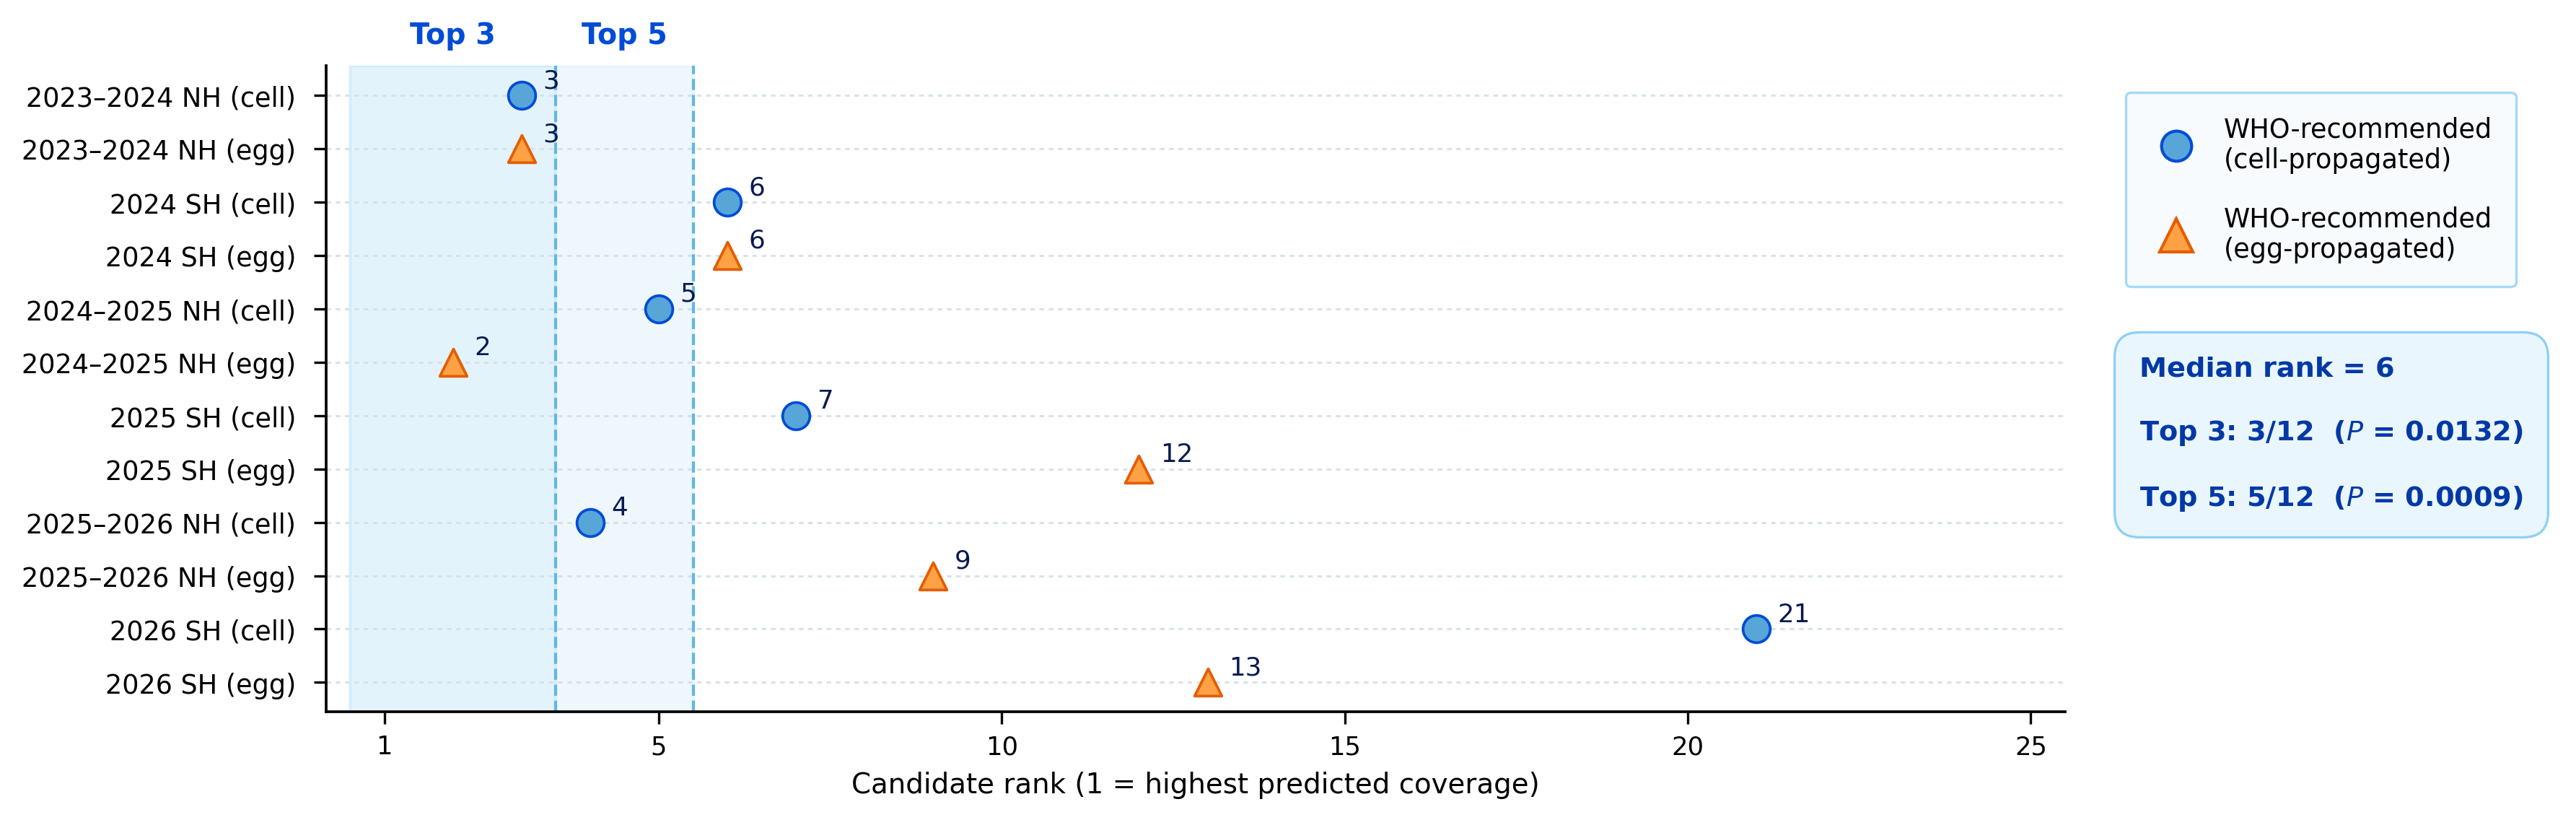

Wrote Figure 4B and plotting data to: /home/chenyh/workspace/fluProfiler/paper/Code/Fig4_vaccine_selection_figure


In [8]:
fig = plt.figure(figsize=(13.2, 4.2), dpi=300)
grid = fig.add_gridspec(1, 2, width_ratios=[5.2, 1.35], wspace=0.035)
ax = fig.add_subplot(grid[0, 0])
info_ax = fig.add_subplot(grid[0, 1])

# Discrete rank cutoffs: ranks 1–3 and 4–5 fall fully inside their bands.
ax.axvspan(0.5, 3.5, color='#9DD6F5', alpha=0.28, zorder=0)
ax.axvspan(3.5, 5.5, color='#CFEAF8', alpha=0.35, zorder=0)
ax.axvline(3.5, color='#62B6E8', lw=1.0, ls='--', zorder=1)
ax.axvline(5.5, color='#62B6E8', lw=1.0, ls='--', zorder=1)
ax.text(2.0, 1.025, 'Top 3', transform=ax.get_xaxis_transform(), ha='center', va='bottom',
        fontsize=9.5, fontweight='bold', color='#004CD6')
ax.text(4.5, 1.025, 'Top 5', transform=ax.get_xaxis_transform(), ha='center', va='bottom',
        fontsize=9.5, fontweight='bold', color='#004CD6')

for passage, marker, facecolor, edgecolor in [
    ('CELL', 'o', CELL_COLOR, CELL_EDGE),
    ('EGG', '^', EGG_COLOR, EGG_EDGE),
]:
    subset = panel_b_data.loc[panel_b_data['passage'].eq(passage)]
    ax.scatter(
        subset['WHO_rank'], subset['y'], s=82, marker=marker,
        facecolor=facecolor, edgecolor=edgecolor, linewidth=0.9, zorder=3,
    )
    for _, row in subset.iterrows():
        ax.annotate(
            str(int(row['WHO_rank'])), (row['WHO_rank'], row['y']),
            xytext=(7, 5), textcoords='offset points', ha='left', va='center',
            fontsize=8.6, color=TEXT_COLOR, zorder=4,
        )

ax.set_yticks(panel_b_data['y'], panel_b_data['y_label'])
ax.set_ylim(len(panel_b_data) - 0.45, -0.55)
ax.set_xlim(0.15, 25.5)
ax.set_xticks([1, 5, 10, 15, 20, 25])
ax.set_xlabel('Candidate rank (1 = highest predicted coverage)', fontsize=9.3)
ax.set_ylabel('')
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#D8E1EA', lw=0.7, ls=(0, (2.2, 2.2)))
ax.xaxis.grid(False)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=8.8, width=0.8, length=4, pad=6)
ax.tick_params(axis='x', labelsize=8.5, width=0.8, length=4)

info_ax.axis('off')
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='none', markersize=10,
           markerfacecolor=CELL_COLOR, markeredgecolor=CELL_EDGE,
           label='WHO-recommended\n(cell-propagated)'),
    Line2D([0], [0], marker='^', linestyle='none', markersize=11,
           markerfacecolor=EGG_COLOR, markeredgecolor=EGG_EDGE,
           label='WHO-recommended\n(egg-propagated)'),
]
legend = info_ax.legend(
    handles=legend_handles, loc='upper left', bbox_to_anchor=(0.02, 0.98),
    frameon=True, fancybox=True, borderpad=0.9, labelspacing=1.2,
    handletextpad=0.8, fontsize=8.8,
)
legend.get_frame().set_facecolor('#F5FAFD')
legend.get_frame().set_edgecolor('#8FD0F5')
legend.get_frame().set_linewidth(0.8)

summary_text = (
    f'Median rank = {median_rank:.0f}\n\n'
    f'Top 3: {top3_count}/{n_evaluations}  ($P$ = {top3_p:.4f})\n\n'
    f'Top 5: {top5_count}/{n_evaluations}  ($P$ = {top5_p:.4f})'
)
info_ax.text(
    0.08, 0.43, summary_text, transform=info_ax.transAxes, ha='left', va='center',
    fontsize=9.2, fontweight='bold', color='#0039A6', linespacing=1.25,
    bbox=dict(boxstyle='round,pad=0.9', facecolor='#EAF6FD', edgecolor='#8FD0F5', linewidth=0.8),
)

fig.subplots_adjust(left=0.205, right=0.985, top=0.87, bottom=0.16)
for extension in ('svg', 'pdf', 'png'):
    fig.savefig(OUTPUT_DIR / f'Fig4B_WHO_candidate_ranks.{extension}', dpi=300, bbox_inches='tight')
plt.show()

panel_b_data.to_csv(OUTPUT_DIR / 'Fig4B_WHO_candidate_ranks.csv', index=False)
print(f'Wrote Figure 4B and plotting data to: {OUTPUT_DIR}')

## Panel C — statistical plots only


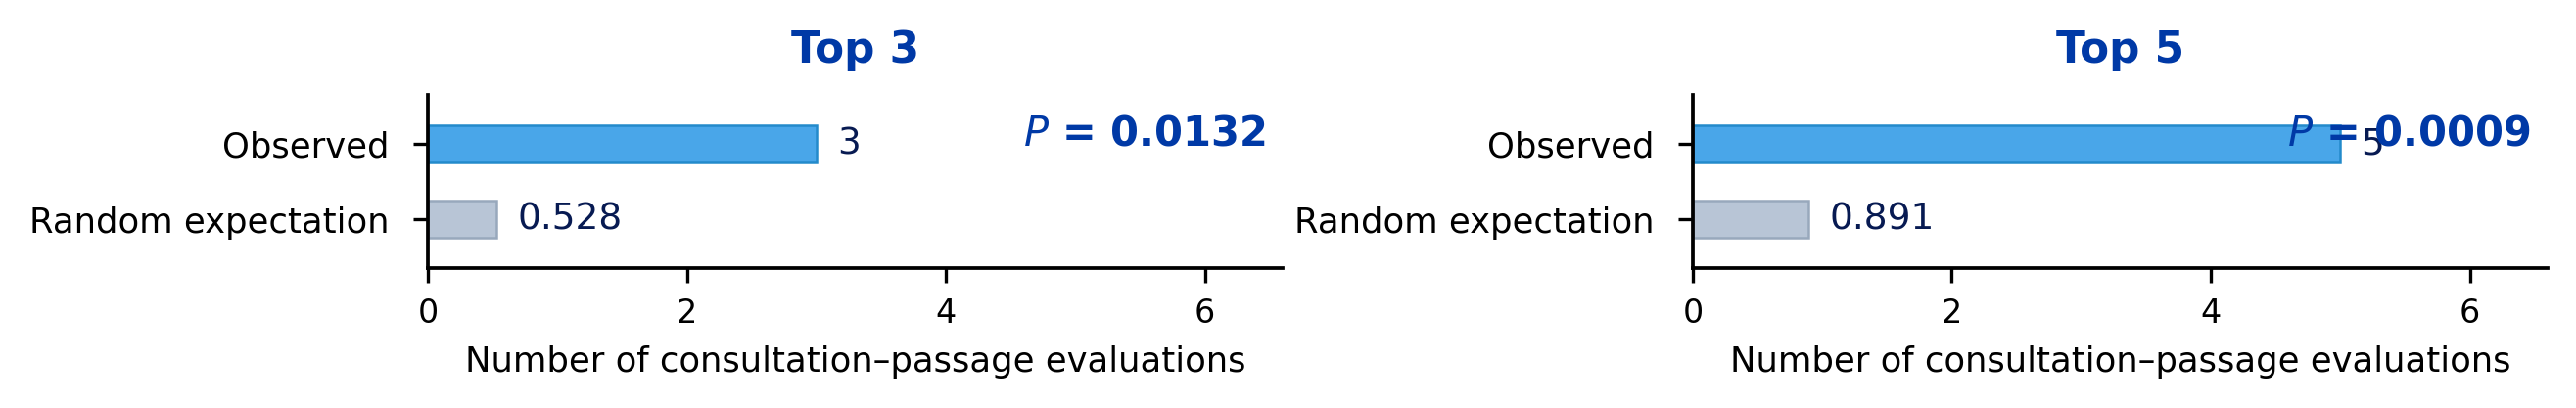

Wrote Figure 4C statistical plots and data to: /home/chenyh/workspace/fluProfiler/paper/Code/Fig4_vaccine_selection_figure


In [15]:
# Figure 4C: Top-3 and Top-5 concordance versus uniform-random expectation.
# Only the statistical charts are drawn; titles, panel labels, boxes, and explanatory text
# can be added later during figure assembly.
CONCORDANCE_COLOR = '#49A6E9'
RANDOM_COLOR = '#B8C5D6'

panel_c_data = (
    random_baseline.set_index('metric')
    .loc[['Top3', 'Top5']]
    .reset_index()
)

def draw_concordance_axis(ax, row, title):
    observed = float(row['WHO_hit_count'])
    random_mean = float(row['random_hit_count_mean'])
    p_value = float(row['empirical_p_value'])

    ax.barh(1, observed, height=0.50, color=CONCORDANCE_COLOR, edgecolor='#238ACB', linewidth=0.6, zorder=2)
    ax.barh(0, random_mean, height=0.50, color=RANDOM_COLOR, edgecolor='#98A8BC', linewidth=0.6, zorder=2)
    ax.text(observed + 0.16, 1, f'{observed:.0f}', ha='left', va='center', fontsize=9, color=TEXT_COLOR)
    ax.text(random_mean + 0.16, 0, f'{random_mean:.3f}', ha='left', va='center', fontsize=9, color=TEXT_COLOR)
    ax.text(0.98, 0.78, f'$P$ = {p_value:.4f}', transform=ax.transAxes, ha='right', va='center',
            fontsize=10, fontweight='bold', color='#0039A6')

    ax.set_title(title, fontsize=10.5, fontweight='bold', color='#0039A6', pad=8)
    ax.set_yticks([1, 0], ['Observed', 'Random expectation'])
    ax.set_xlim(0, 6.6)
    ax.set_xticks([0, 2, 4, 6])
    ax.set_ylim(-0.65, 1.65)
    ax.set_xlabel('Number of consultation–passage evaluations', fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(0.9)
    ax.tick_params(axis='y', length=3.5, width=0.8, labelsize=8.5, pad=6)
    ax.tick_params(axis='x', length=3.5, width=0.8, labelsize=8)
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)

fig, axes = plt.subplots(1, 2, figsize=(8.8, 1), dpi=300)
for ax, (_, row), title in zip(axes, panel_c_data.iterrows(), ['Top 3', 'Top 5']):
    draw_concordance_axis(ax, row, title)
fig.subplots_adjust(left=0.17, right=0.99, top=0.84, bottom=0.25, wspace=0.48)

for extension in ('svg', 'pdf', 'png'):
    fig.savefig(OUTPUT_DIR / f'Fig4C_Top3_Top5_concordance.{extension}', dpi=300, bbox_inches='tight')
plt.show()

panel_c_data.to_csv(OUTPUT_DIR / 'Fig4C_Top3_Top5_concordance.csv', index=False)
print(f'Wrote Figure 4C statistical plots and data to: {OUTPUT_DIR}')
